In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned session-level dataset
df = pd.read_csv("../Data/processed/acn_caltech_2019_clean.csv")

print("Dataset shape:", df.shape)

df[
    [
        "stationID",
        "kWhDelivered",
        "connected_hours",
        "charging_hours"
    ]
].head(10)

Dataset shape: (10607, 24)


,stationID,kWhDelivered,connected_hours,charging_hours
0,2-39-138-566,0.900,0.960000,0.976667
1,2-39-79-379,12.534,8.504167,2.114722
2,2-39-138-566,0.883,0.656667,0.672778
3,2-39-138-566,0.879,0.920556,0.670833
4,2-39-79-378,16.136,4.951389,4.891667
5,2-39-139-28,2.917,1.730556,1.140556
6,2-39-79-377,1.280,4.897222,4.141667
7,2-39-125-21,13.273,2.519722,2.118889
8,2-39-127-19,36.608,8.761667,5.950278
9,2-39-79-382,8.855,8.753333,3.200000


In [2]:
# Create idle/occupied-but-not-charging duration
df["idle_hours"] = df["connected_hours"] - df["charging_hours"]

# Keep only physically consistent sessions for the ML model
anomaly_data = df[
    (df["kWhDelivered"] > 0) &
    (df["connected_hours"] > 0) &
    (df["charging_hours"].notna()) &
    (df["charging_hours"] >= 0) &
    (df["charging_hours"] <= df["connected_hours"]) &
    (df["idle_hours"] >= 0)
].copy()

anomaly_features = [
    "kWhDelivered",
    "connected_hours",
    "charging_hours",
    "idle_hours"
]

print("Original sessions:", len(df))
print("Sessions used for anomaly detection:", len(anomaly_data))
print("Excluded sessions:", len(df) - len(anomaly_data))

print("\nFeature summary:")
print(anomaly_data[anomaly_features].describe().round(2))

Original sessions: 10607
Sessions used for anomaly detection: 9817
Excluded sessions: 790

Feature summary:
       kWhDelivered  connected_hours  charging_hours  idle_hours
count       9817.00          9817.00         9817.00     9817.00
mean           9.05             6.11            2.82        3.28
std            9.20             5.72            3.74        4.36
min            0.50             0.09            0.00        0.00
25%            2.84             2.41            1.18        0.13
50%            6.32             5.91            1.96        2.05
75%           12.02             8.63            3.62        5.68
max           75.53           214.32          200.02      138.64


In [3]:
from sklearn.preprocessing import StandardScaler

X_anomaly = anomaly_data[anomaly_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_anomaly)

print("Original feature means:")
print(X_anomaly.mean().round(2))

print("\nScaled feature means:")
print(np.round(X_scaled.mean(axis=0), 3))

print("\nScaled feature standard deviations:")
print(np.round(X_scaled.std(axis=0), 3))

Original feature means:
kWhDelivered       9.05
connected_hours    6.11
charging_hours     2.82
idle_hours         3.28
dtype: float64

Scaled feature means:
[ 0. -0.  0.  0.]

Scaled feature standard deviations:
[1. 1. 1. 1.]


In [4]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Train the model and classify sessions
anomaly_labels = iso_forest.fit_predict(X_scaled)

# Isolation Forest returns:
#  1 = normal
# -1 = anomaly

anomaly_data["anomaly"] = anomaly_labels

# Convert to easier labels for dashboard use
anomaly_data["status"] = anomaly_data["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Classification counts:")
print(anomaly_data["status"].value_counts())

print("\nPercentages:")
print(
    (anomaly_data["status"].value_counts(normalize=True) * 100)
    .round(2)
)

Classification counts:
status
Normal     9326
Anomaly     491
Name: count, dtype: int64

Percentages:
status
Normal     95.0
Anomaly     5.0
Name: proportion, dtype: float64


In [5]:
# Calculate anomaly score
# Negative sign makes larger values = more anomalous
anomaly_data["anomaly_score"] = -iso_forest.decision_function(X_scaled)

# Show the 15 most anomalous sessions
top_anomalies = (
    anomaly_data[
        [
            "sessionID",
            "stationID",
            "kWhDelivered",
            "connected_hours",
            "charging_hours",
            "idle_hours",
            "anomaly_score",
            "status"
        ]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(15)
)

top_anomalies.round(2)

,sessionID,stationID,kWhDelivered,connected_hours,charging_hours,idle_hours,anomaly_score,status
4640,2_39_138_29_2019-05-23 16:18:45.048941,2-39-138-29,1.08,118.91,76.58,42.33,0.27,Anomaly
5886,2_39_95_27_2019-07-08 00:11:53.153549,2-39-95-27,12.17,75.68,42.63,33.05,0.26,Anomaly
2477,2_39_79_381_2019-03-19 05:19:25.541370,2-39-79-381,42.38,39.90,20.51,19.39,0.25,Anomaly
2826,2_39_91_437_2019-03-29 16:00:02.031826,2-39-91-437,13.20,214.32,200.02,14.31,0.25,Anomaly
2391,2_39_89_25_2019-03-16 01:24:57.301888,2-39-89-25,53.28,47.05,7.95,39.09,0.24,Anomaly
4706,2_39_131_30_2019-05-25 23:50:42.993780,2-39-131-30,50.23,42.34,7.51,34.83,0.24,Anomaly
5109,2_39_79_382_2019-06-10 15:37:57.311736,2-39-79-382,0.90,49.50,32.72,16.78,0.24,Anomaly
5079,2_39_127_19_2019-06-07 22:50:13.078217,2-39-127-19,14.88,50.42,35.95,14.48,0.23,Anomaly
1350,2_39_78_364_2019-02-12 18:48:13.706276,2-39-78-364,52.37,33.24,9.27,23.97,0.23,Anomaly
1485,2_39_95_27_2019-02-16 02:31:02.405020,2-39-95-27,44.90,74.85,74.65,0.20,0.23,Anomaly


In [6]:
comparison = (
    anomaly_data
    .groupby("status")[anomaly_features]
    .mean()
    .round(2)
)

print("Average session characteristics:")
print(comparison)

print("\nMedian session characteristics:")
print(
    anomaly_data
    .groupby("status")[anomaly_features]
    .median()
    .round(2)
)

Average session characteristics:
         kWhDelivered  connected_hours  charging_hours  idle_hours
status                                                            
Anomaly         28.31            17.81            9.01        8.80
Normal           8.03             5.49            2.49        2.99

Median session characteristics:
         kWhDelivered  connected_hours  charging_hours  idle_hours
status                                                            
Anomaly         32.62            13.71            7.42        4.44
Normal           6.09             5.53            1.90        1.99


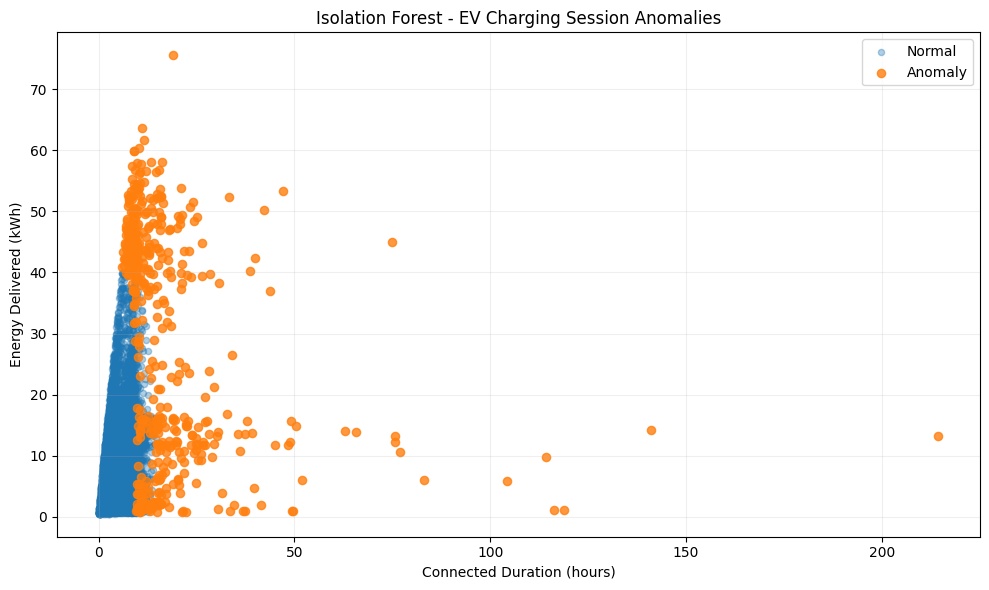

In [7]:
plt.figure(figsize=(10, 6))

normal = anomaly_data[anomaly_data["status"] == "Normal"]
anomalies = anomaly_data[anomaly_data["status"] == "Anomaly"]

plt.scatter(
    normal["connected_hours"],
    normal["kWhDelivered"],
    alpha=0.35,
    s=20,
    label="Normal"
)

plt.scatter(
    anomalies["connected_hours"],
    anomalies["kWhDelivered"],
    alpha=0.8,
    s=35,
    label="Anomaly"
)

plt.xlabel("Connected Duration (hours)")
plt.ylabel("Energy Delivered (kWh)")
plt.title("Isolation Forest - EV Charging Session Anomalies")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [8]:
contamination_results = []

for contamination in [0.02, 0.03, 0.05, 0.07, 0.10]:
    
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )
    
    labels = model.fit_predict(X_scaled)
    
    anomaly_count = np.sum(labels == -1)
    
    contamination_results.append({
        "contamination": contamination,
        "anomalies_detected": anomaly_count,
        "percentage": (anomaly_count / len(X_scaled)) * 100
    })

contamination_df = pd.DataFrame(contamination_results)

print(contamination_df)

   contamination  anomalies_detected  percentage
0           0.02                 197    2.006723
1           0.03                 295    3.004991
2           0.05                 491    5.001528
3           0.07                 688    7.008251
4           0.10                 982   10.003056


In [9]:
# Keep the final 5% Isolation Forest model
final_iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

final_labels = final_iso_forest.fit_predict(X_scaled)

anomaly_data["anomaly"] = final_labels
anomaly_data["status"] = np.where(
    final_labels == -1,
    "Anomaly",
    "Normal"
)

# Higher score = more anomalous
anomaly_data["anomaly_score"] = -final_iso_forest.decision_function(X_scaled)

# Save results
output_path = "../Data/processed/acn_caltech_2019_anomalies.csv"

anomaly_data.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows saved:", len(anomaly_data))
print("\nStatus counts:")
print(anomaly_data["status"].value_counts())

Saved: ../Data/processed/acn_caltech_2019_anomalies.csv
Rows saved: 9817

Status counts:
status
Normal     9326
Anomaly     491
Name: count, dtype: int64


In [10]:
print(anomaly_data.columns.tolist())

print("\nTimestamp sample:")

timestamp_cols = [
    "connectionTime_local",
    "disconnectTime_local",
    "doneChargingTime_local"
]

print(
    anomaly_data[timestamp_cols]
    .head()
    .to_string(index=False)
)

['_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'connectionTime_local', 'disconnectTime_local', 'doneChargingTime_local', 'connected_hours', 'charging_hours', 'date', 'hour', 'day_of_week', 'day_name', 'month', 'is_weekend', 'idle_hours', 'anomaly', 'status', 'anomaly_score']

Timestamp sample:
     connectionTime_local      disconnectTime_local    doneChargingTime_local
2019-01-01 10:09:17-08:00 2019-01-01 18:39:32-08:00 2019-01-01 12:16:10-08:00
2019-01-01 11:18:53-08:00 2019-01-01 12:14:07-08:00 2019-01-01 11:59:08-08:00
2019-01-01 13:05:57-08:00 2019-01-01 18:03:02-08:00 2019-01-01 17:59:27-08:00
2019-01-01 13:08:49-08:00 2019-01-01 14:52:39-08:00 2019-01-01 14:17:15-08:00
2019-01-01 13:10:03-08:00 2019-01-01 18:03:53-08:00 2019-01-01 17:18:33-08:00
